<a href="https://colab.research.google.com/github/ikramyoumba1/BigDataAanlysis/blob/main/TP03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print("===Highway traffic data analysis ===")

===Highway traffic data analysis ===


**Step 1: Loading and exploring the data**

In [ ]:
def load_and_explore_data(file_path):

    print("1. Loading data...")

    try:
       # Download Data
        df = pd.read_csv(file_path)
        print(f"✓ Data has been successfully loaded: {len(df)} Class, {len(df.columns)} Column")

        # Basic Information
        print("\n2. Basic information about the data:")
        print(f"Dimensions: {df.shape}")
        print(f"\n Column names: {df.columns.tolist()}")

        print("\n3. Data types:")
        print(df.dtypes)

        print("\n4. Missing values:")
        missing_data = df.isnull().sum()
        print(missing_data[missing_data > 0])

        print("\n5.Sample of the data:")
        print(df.head(10))

        print("\n6.Descriptive statistics:")
        print(df.describe())

        return df

    except Exception as e:
        print(f"✗ Error loading data: {e}")
        return None

# Download Data
traffic_data = load_and_explore_data('/content/drive/MyDrive/Metro_Interstate_Traffic_Volume.csv')

1. Loading data...
✓ Data has been successfully loaded: 48204 Class, 9 Column

2. Basic information about the data:
Dimensions: (48204, 9)

 Column names: ['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']

3. Data types:
holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object

4. Missing values:
holiday    48143
dtype: int64

5.Sample of the data:
  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14

**Stage 2: Data Cleaning and Processing**

In [ ]:
def clean_traffic_data(df):

    print("\n===Data cleaning===")

   # Data Copy
    cleaned_df = df.copy()

   # 1. Checking for missing values
    print("1. Checking for missing values:")
    missing_before = cleaned_df.isnull().sum()
    print(missing_before)

    # 2. Handling Missing Values if Present
    for column in cleaned_df.columns:
        if cleaned_df[column].isnull().sum() > 0:
            if cleaned_df[column].dtype in ['float64', 'int64']:
                cleaned_df[column].fillna(cleaned_df[column].median(), inplace=True)
            else:
                cleaned_df[column].fillna(cleaned_df[column].mode()[0], inplace=True)

    # 3. Remove Duplicates
    initial_count = len(cleaned_df)
    cleaned_df.drop_duplicates(inplace=True)
    final_count = len(cleaned_df)
    print(f"\n2. Duplicates: Removed {initial_count - final_count} Repeated class")

    # 4. Convert the date to an appropriate format
    if 'date_time' in cleaned_df.columns:
        cleaned_df['date_time'] = pd.to_datetime(cleaned_df['date_time'])

        # Extracting Date and Time Components
        cleaned_df['year'] = cleaned_df['date_time'].dt.year
        cleaned_df['month'] = cleaned_df['date_time'].dt.month
        cleaned_df['day'] = cleaned_df['date_time'].dt.day
        cleaned_df['hour'] = cleaned_df['date_time'].dt.hour
        cleaned_df['day_of_week'] = cleaned_df['date_time'].dt.day_name()
        cleaned_df['is_weekend'] = cleaned_df['day_of_week'].isin(['Saturday', 'Sunday'])
        cleaned_df['month_year'] = cleaned_df['date_time'].dt.to_period('M')

    # 5. Handling Outliers
    numerical_columns = cleaned_df.select_dtypes(include=[np.number]).columns

    print(f"\n3. Digital variables: {list(numerical_columns)}")

    # 6. Create New Categories
    if 'hour' in cleaned_df.columns:
        cleaned_df['time_of_day'] = pd.cut(cleaned_df['hour'],
                                         bins=[0, 6, 12, 18, 24],
                                         labels=['Night', 'Morning', 'back', 'Evening'],
                                         include_lowest=True)

    if 'month' in cleaned_df.columns:
        cleaned_df['season'] = pd.cut(cleaned_df['month'],
                                    bins=[0, 3, 6, 9, 12],
                                    labels=['Winter', 'Spring', 'Summer', 'Autumn'],
                                    include_lowest=True)

    print(f"\n✓ Data cleaning is complete: {len(cleaned_df)} Class")
    return cleaned_df

# Data Cleaning
cleaned_traffic = clean_traffic_data(traffic_data)


===Data cleaning===
1. Checking for missing values:
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

2. Duplicates: Removed 17 Repeated class

3. Digital variables: ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume', 'year', 'month', 'day', 'hour']

✓ Data cleaning is complete: 48187 Class


**Stage 3: Exploratory Data Analysis**


=== Comprehensive Exploratory Analysis===


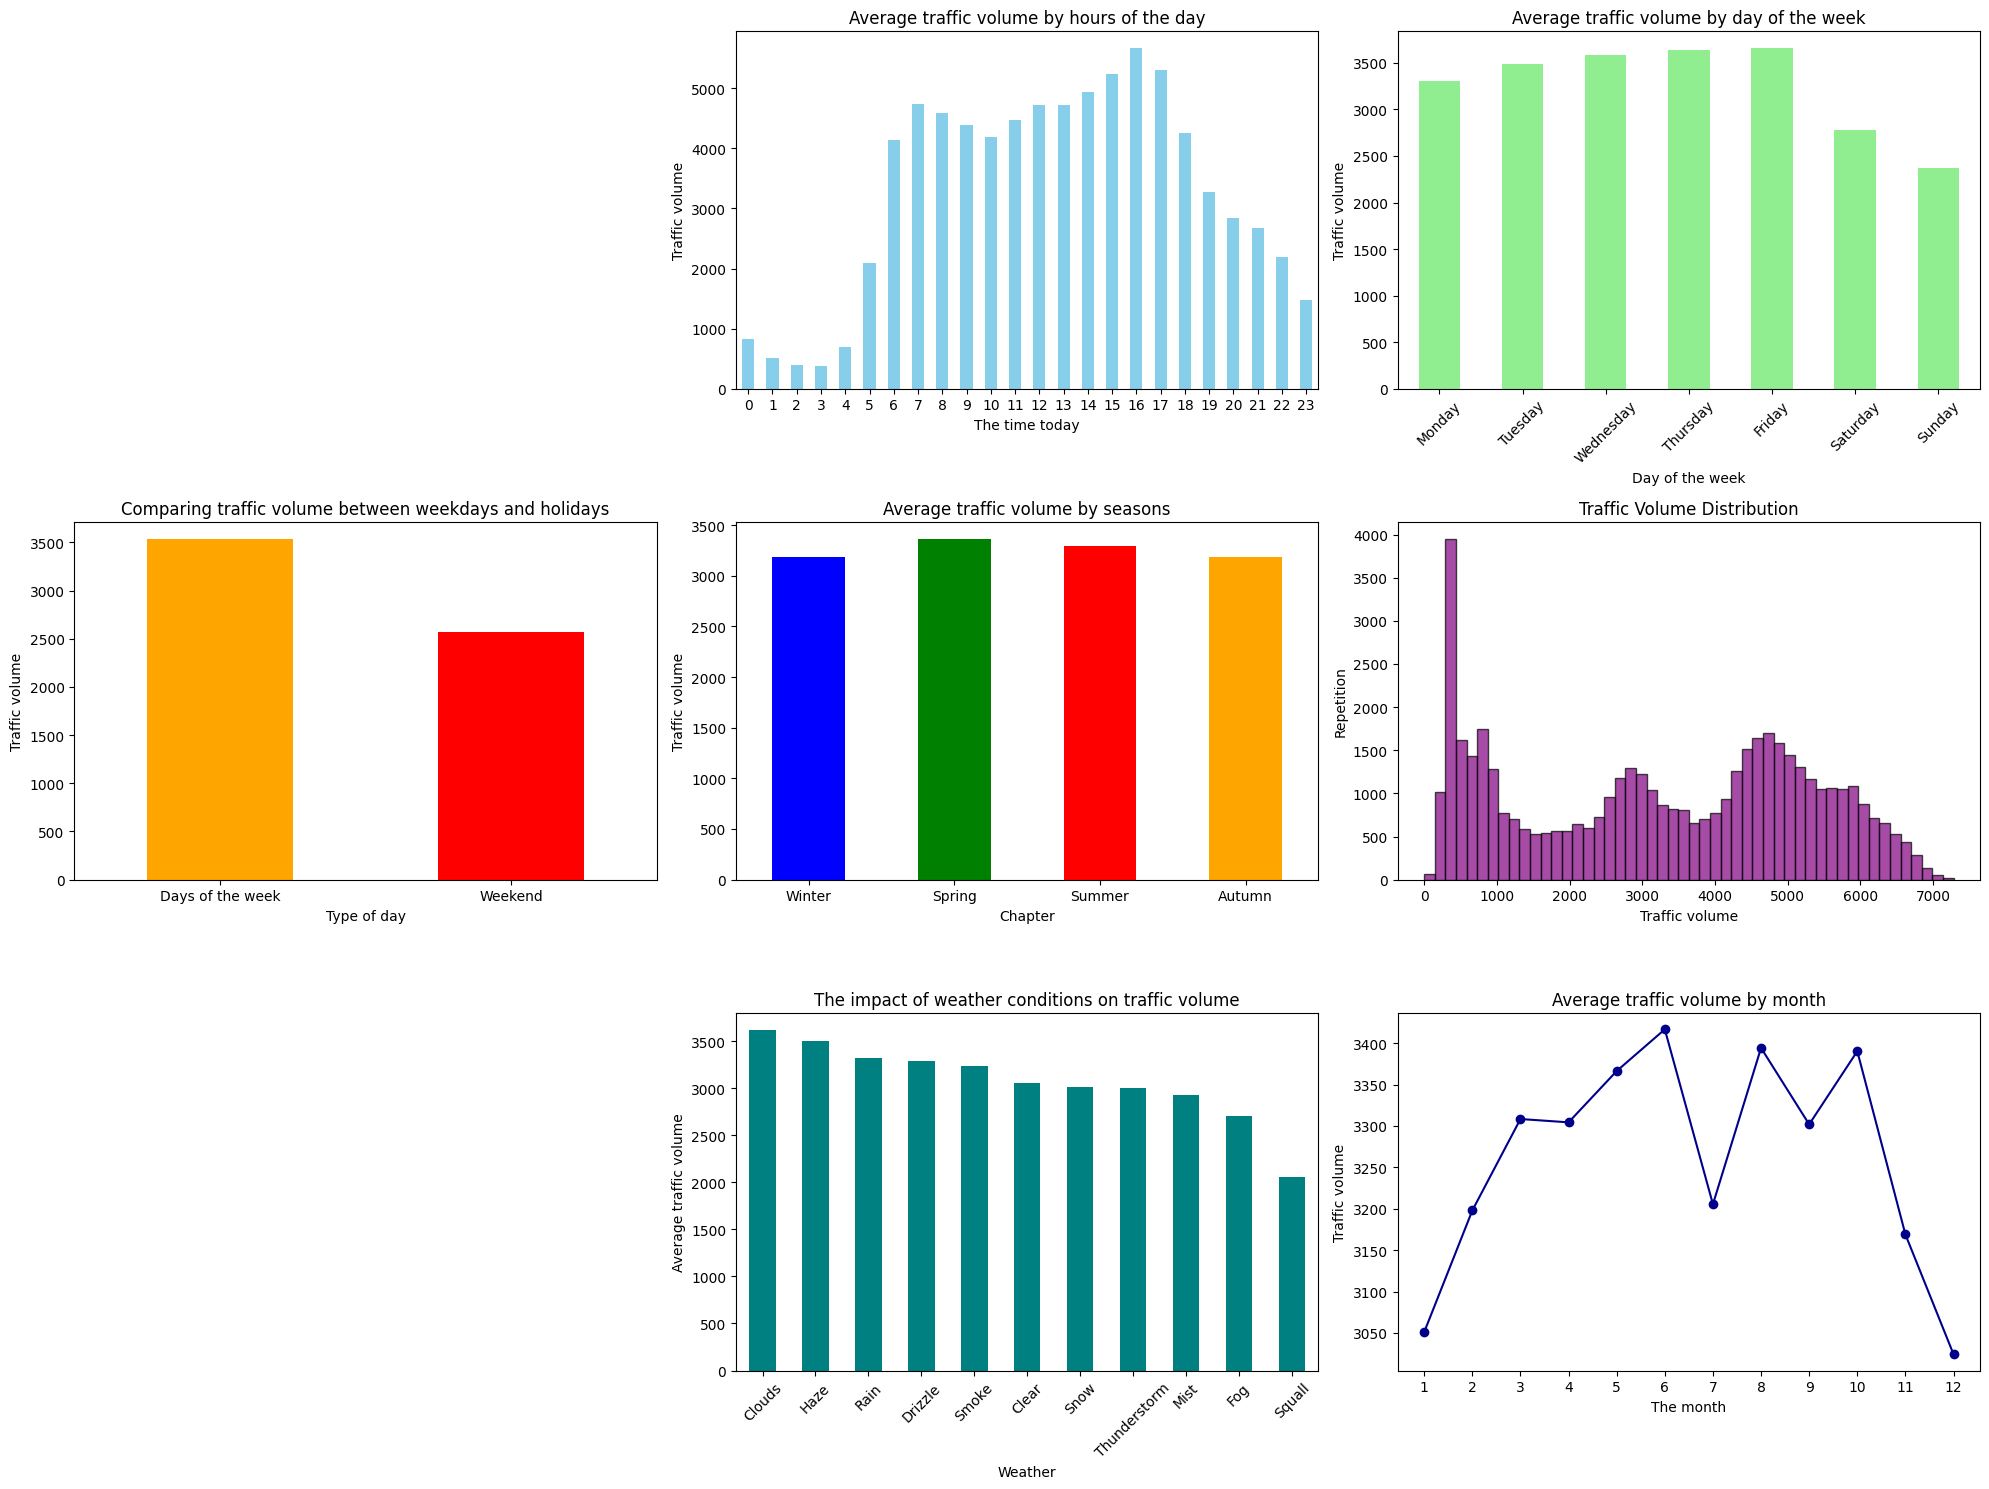


=== Statistical analysis===
Traffic volume statistics:
• average: 3259.62
• The intermediary: 3379.00
• Standard deviation: 1986.95
• Maximum value: 7280.00
• Minimum value: 0.00
• Scope: 7280.00

 Weather Impact Analysis:
              Average Traffic Volume  Number of registrations
weather_main                                                 
Clouds                       3617.99                    15158
Haze                         3502.10                     1360
Rain                         3317.91                     5672
Drizzle                      3292.19                     1820
Smoke                        3237.65                       20
Clear                        3055.61                    13384
Snow                         3016.32                     2875
Thunderstorm                 2999.43                     1033
Mist                         2933.34                     5949
Fog                          2703.72                      912
Squall                       206

In [ ]:
def comprehensive_eda(df):

    print("\n=== Comprehensive Exploratory Analysis===")

    # 1. Temporal Analysis
    plt.figure(figsize=(20, 15))



    # Figure 2: Traffic volume by hour of the day
    plt.subplot(3, 3, 2)
    if 'hour' in df.columns and 'traffic_volume' in df.columns:
        df.groupby('hour')['traffic_volume'].mean().plot(kind='bar', color='skyblue')
        plt.title('Average traffic volume by hours of the day')
        plt.xlabel('The time today')
        plt.ylabel('Traffic volume')
        plt.xticks(rotation=0)

   # Figure 3: Traffic volume by days of the week
    plt.subplot(3, 3, 3)
    if 'day_of_week' in df.columns and 'traffic_volume' in df.columns:
        day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)
        df.groupby('day_of_week')['traffic_volume'].mean().plot(kind='bar', color='lightgreen')
        plt.title('Average traffic volume by day of the week')
        plt.xlabel('Day of the week')
        plt.ylabel('Traffic volume')
        plt.xticks(rotation=45)

   # Figure 4: Comparison between weekdays and holidays
    plt.subplot(3, 3, 4)
    if 'is_weekend' in df.columns and 'traffic_volume' in df.columns:
        df.groupby('is_weekend')['traffic_volume'].mean().plot(kind='bar', color=['orange', 'red'])
        plt.title('Comparing traffic volume between weekdays and holidays')
        plt.xlabel('Type of day')
        plt.ylabel('Traffic volume')
        plt.xticks([0, 1], ['Days of the week', 'Weekend'], rotation=0)

    # Figure 5: Traffic Volume by Season
    plt.subplot(3, 3, 5)
    if 'season' in df.columns and 'traffic_volume' in df.columns:
        df.groupby('season')['traffic_volume'].mean().plot(kind='bar', color=['blue', 'green', 'red', 'orange'])
        plt.title('Average traffic volume by seasons')
        plt.xlabel('Chapter')
        plt.ylabel('Traffic volume')
        plt.xticks(rotation=0)

    # Figure 6: Traffic Volume Distribution
    plt.subplot(3, 3, 6)
    if 'traffic_volume' in df.columns:
        plt.hist(df['traffic_volume'], bins=50, alpha=0.7, color='purple', edgecolor='black')
        plt.title('Traffic Volume Distribution')
        plt.xlabel('Traffic volume')
        plt.ylabel('Repetition')



# Figure 8: The effect of weather on traffic volume
    plt.subplot(3, 3, 8)
    if 'weather_main' in df.columns and 'traffic_volume' in df.columns:
        weather_traffic = df.groupby('weather_main')['traffic_volume'].mean().sort_values(ascending=False)
        weather_traffic.plot(kind='bar', color='teal')
        plt.title('The impact of weather conditions on traffic volume')
        plt.xlabel('Weather')
        plt.ylabel('Average traffic volume')
        plt.xticks(rotation=45)

    # Figure 9: Traffic volume by month
    plt.subplot(3, 3, 9)
    if 'month' in df.columns and 'traffic_volume' in df.columns:
        df.groupby('month')['traffic_volume'].mean().plot(kind='line', marker='o', color='darkblue')
        plt.title('Average traffic volume by month')
        plt.xlabel('The month')
        plt.ylabel('Traffic volume')
        plt.xticks(range(1, 13))

    plt.tight_layout()
    plt.show()



    #3. Statistical Analysis
    print("\n=== Statistical analysis===")

    if 'traffic_volume' in df.columns:
        print(f"Traffic volume statistics:")
        print(f"• average: {df['traffic_volume'].mean():.2f}")
        print(f"• The intermediary: {df['traffic_volume'].median():.2f}")
        print(f"• Standard deviation: {df['traffic_volume'].std():.2f}")
        print(f"• Maximum value: {df['traffic_volume'].max():.2f}")
        print(f"• Minimum value: {df['traffic_volume'].min():.2f}")
        print(f"• Scope: {df['traffic_volume'].max() - df['traffic_volume'].min():.2f}")

    # 4.Weather analysis
    if 'weather_main' in df.columns:
        print(f"\n Weather Impact Analysis:")
        weather_analysis = df.groupby('weather_main').agg({
            'traffic_volume': ['mean', 'count']
        }).round(2)
        weather_analysis.columns = ['Average Traffic Volume', 'Number of registrations']
        print(weather_analysis.sort_values('Average Traffic Volume', ascending=False))

    # 5. Time Analysis
    if 'time_of_day' in df.columns:
        print(f"\n Daily time analysis:")
        time_analysis = df.groupby('time_of_day').agg({
            'traffic_volume': ['mean', 'std']
        }).round(2)
        time_analysis.columns = ['Average Traffic Volume', 'Standard deviation']
        print(time_analysis)

# Exploratory Analysis Application
comprehensive_eda(cleaned_traffic)

**Save as CSV file**

In [ ]:
cleaned_traffic.to_csv('cleaned_traffic_data.csv', index=False)
print("✓The cleaned data has been saved as a file CSV: cleaned_traffic_data.csv")

✓The cleaned data has been saved as a file CSV: cleaned_traffic_data.csv


# **conclusion**